In [24]:
!pip install mtcnn facenet-pytorch opencv-python scikit-learn matplotlib

In [25]:
import os
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

from mtcnn import MTCNN
from facenet_pytorch import InceptionResnetV1
import torch

In [26]:
# Initialize MTCNN for face detection
detector = MTCNN()

# Load pretrained FaceNet model
model = InceptionResnetV1(pretrained='vggface2').eval()

print("Models loaded successfully!")

Models loaded successfully!


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
DATASET_PATH = "/content/drive/MyDrive/dataset"

In [29]:
def extract_face(image_path, required_size=(160, 160)):
    img = cv2.imread(image_path)

    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = detector.detect_faces(img_rgb)

    if len(results) == 0:
        return None

    # Take first detected face
    x, y, w, h = results[0]['box']

    x, y = abs(x), abs(y)
    face = img_rgb[y:y+h, x:x+w]

    # Resize
    face = cv2.resize(face, required_size)

    return face

In [30]:
def get_embedding(face_pixels):
    face_pixels = face_pixels.astype('float32')

    # Normalize
    face_pixels = (face_pixels - face_pixels.mean()) / face_pixels.std()

    face_tensor = torch.tensor(face_pixels).permute(2, 0, 1).unsqueeze(0)

    with torch.no_grad():
        embedding = model(face_tensor)

    return embedding[0].numpy()

In [31]:
X = []
y = []

for person_name in tqdm(os.listdir(DATASET_PATH)):
    person_path = os.path.join(DATASET_PATH, person_name)

    if not os.path.isdir(person_path):
        continue

    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)

        face = extract_face(img_path)

        if face is None:
            continue

        embedding = get_embedding(face)

        X.append(embedding)
        y.append(person_name)

X = np.array(X)
y = np.array(y)

print("Embeddings shape:", X.shape)
print("Labels shape:", y.shape)

100%|██████████| 3/3 [01:27<00:00, 29.14s/it]

Embeddings shape: (18, 512)
Labels shape: (18,)


In [32]:
import pickle

data = {"embeddings": X, "labels": y}

with open("face_embeddings.pkl", "wb") as f:
    pickle.dump(data, f)

print("Embeddings saved successfully!")

Embeddings saved successfully!


In [33]:
print("Sample label:", y[0])
print("Embedding vector (first 5 values):", X[0][:5])

Sample label: Vansh
Embedding vector (first 5 values): [ 0.03506764 -0.07034699 -0.01892866  0.00725022  0.01232223]


In [34]:
import pickle

with open("face_embeddings.pkl", "rb") as f:
    data = pickle.load(f)

X = data["embeddings"]
y = data["labels"]

print("Loaded embeddings:", X.shape)

Loaded embeddings: (18, 512)


In [35]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['Ryan Gosling' 'Vansh']


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

In [37]:
from sklearn.metrics.pairwise import cosine_similarity

def recognize_face_cosine(test_embedding, X_train, y_train, threshold=0.5):
    similarities = cosine_similarity([test_embedding], X_train)[0]

    best_idx = np.argmax(similarities)
    best_score = similarities[best_idx]

    if best_score > threshold:
        return y_train[best_idx], best_score
    else:
        return "Unknown", best_score

In [38]:
def recognize_face_euclidean(test_embedding, X_train, y_train, threshold=0.8):
    distances = np.linalg.norm(X_train - test_embedding, axis=1)

    best_idx = np.argmin(distances)
    best_score = distances[best_idx]

    if best_score < threshold:
        return y_train[best_idx], best_score
    else:
        return "Unknown", best_score

In [39]:
y_pred_cosine = []
y_pred_euclidean = []

for emb in X_test:
    pred_cos, _ = recognize_face_cosine(emb, X_train, y_train)
    pred_euc, _ = recognize_face_euclidean(emb, X_train, y_train)

    y_pred_cosine.append(pred_cos)
    y_pred_euclidean.append(pred_euc)

In [40]:
def convert_predictions(preds):
    result = []
    for p in preds:
        if p == "Unknown":
            result.append(-1)
        else:
            result.append(p)
    return result

y_pred_cosine = convert_predictions(y_pred_cosine)
y_pred_euclidean = convert_predictions(y_pred_euclidean)

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred, name):
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted', zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, average='weighted', zero_division=0))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted', zero_division=0))

evaluate(y_test, y_pred_cosine, "Cosine Similarity")
evaluate(y_test, y_pred_euclidean, "Euclidean Distance")


Cosine Similarity Results:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Euclidean Distance Results:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


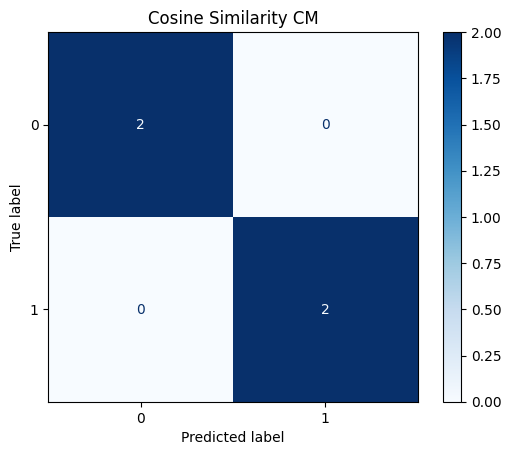

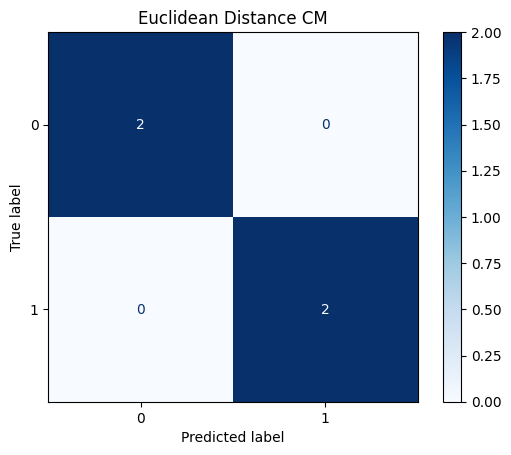

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()

plot_cm(y_test, y_pred_cosine, "Cosine Similarity CM")
plot_cm(y_test, y_pred_euclidean, "Euclidean Distance CM")

In [43]:
thresholds = [0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    preds = []

    for emb in X_test:
        pred, _ = recognize_face_cosine(emb, X_train, y_train, threshold=t)
        preds.append(pred)

    preds = convert_predictions(preds)

    print(f"\nThreshold: {t}")
    print("Accuracy:", accuracy_score(y_test, preds))


Threshold: 0.3
Accuracy: 1.0

Threshold: 0.4
Accuracy: 1.0

Threshold: 0.5
Accuracy: 1.0

Threshold: 0.6
Accuracy: 1.0


In [44]:
unknown_count = 0
known_count = 0

for emb, true_label in zip(X_test, y_test):
    pred, score = recognize_face_cosine(emb, X_train, y_train, threshold=0.5)

    if pred == "Unknown":
        unknown_count += 1
    else:
        known_count += 1

print("Known predictions:", known_count)
print("Unknown predictions:", unknown_count)

Known predictions: 4
Unknown predictions: 0


In [45]:
pred, score = recognize_face_cosine(emb, X_train, y_train, threshold=0.8)

In [46]:
!pip install opencv-python